# Credit Risk — Data Preparation
Cleans, renames columns, imputes missing values, scales features, and saves the output.

In [2]:
import sys, os
# Add project root to path
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline
matplotlib.rcParams['figure.dpi'] = 100

from src.LoadData import cs_train

print('Libraries loaded OK')

Loaded CSV: c:\Users\User\Downloads\Credit-risk-prediction-main\Credit-risk-prediction-main\data\cs-training.csv | Shape: (150000, 12)
   Unnamed: 0  SeriousDlqin2yrs  RevolvingUtilizationOfUnsecuredLines  age  \
0           1                 1                              0.766127   45   
1           2                 0                              0.957151   40   
2           3                 0                              0.658180   38   
3           4                 0                              0.233810   30   
4           5                 0                              0.907239   49   

   NumberOfTime30-59DaysPastDueNotWorse  DebtRatio  MonthlyIncome  \
0                                     2   0.802982         9120.0   
1                                     0   0.121876         2600.0   
2                                     1   0.085113         3042.0   
3                                     0   0.036050         3300.0   
4                                     1   0.024926 

## 1. Load & Rename Columns

In [3]:
df = cs_train.copy()

# Drop unnecessary index column
df.drop(columns=['Unnamed: 0'], inplace=True)

# Rename columns to short, readable names
rename_map = {
    'SeriousDlqin2yrs':                        'default',
    'RevolvingUtilizationOfUnsecuredLines':     'util_rate',
    'age':                                      'age',
    'NumberOfTime30-59DaysPastDueNotWorse':     'late_30_59',
    'DebtRatio':                                'debt_ratio',
    'MonthlyIncome':                            'income',
    'NumberOfOpenCreditLinesAndLoans':          'open_loans',
    'NumberOfTimes90DaysLate':                  'late_90_plus',
    'NumberRealEstateLoansOrLines':             'real_estate_loans',
    'NumberOfTime60-89DaysPastDueNotWorse':     'late_60_89',
    'NumberOfDependents':                       'dependents'
}
df.rename(columns=rename_map, inplace=True)

print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
df.head()

Shape: 150,000 rows x 11 columns


,default,util_rate,age,late_30_59,debt_ratio,income,open_loans,late_90_plus,real_estate_loans,late_60_89,dependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


## 2. Missing Values

In [4]:
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Percentage (%)': (df.isnull().sum() / len(df) * 100).round(2)
})
missing[missing['Missing Count'] > 0]

,Missing Count,Percentage (%)
income,29731,19.82
dependents,3924,2.62


## 3. Duplicates & Invalid Ages

In [5]:
print(f'Duplicated rows : {df.duplicated().sum():,}')

n_invalid = (df['age'] == 0).sum()
print(f'Invalid ages (0): {n_invalid}')

# Replace 0-age with NaN
df.loc[df['age'] == 0, 'age'] = np.nan
print(f'NaN in age after fix: {df["age"].isnull().sum()}')

Duplicated rows : 609
Invalid ages (0): 1
NaN in age after fix: 1


In [6]:
df.drop_duplicates(inplace=True)
print(f"Shape after removing duplicates: {df.shape}")

Shape after removing duplicates: (149391, 11)


## 4. Distributions — Columns with Missing Values

In [7]:
missing_cols = ['income', 'dependents', 'age']

print('Skewness:')
print(df[missing_cols].skew().sort_values().round(3))
print('\nDescriptive Statistics:')
df[missing_cols].describe().T.round(2)

Skewness:
age             0.193
dependents      1.583
income        114.017
dtype: float64

Descriptive Statistics:


,count,mean,std,min,25%,50%,75%,max
income,120170.0,6675.10,14389.58,0.0,3400.0,5400.0,8250.0,3008750.0
dependents,145563.0,0.76,1.12,0.0,0.0,0.0,1.0,20.0
age,149390.0,52.31,14.73,21.0,41.0,52.0,63.0,109.0


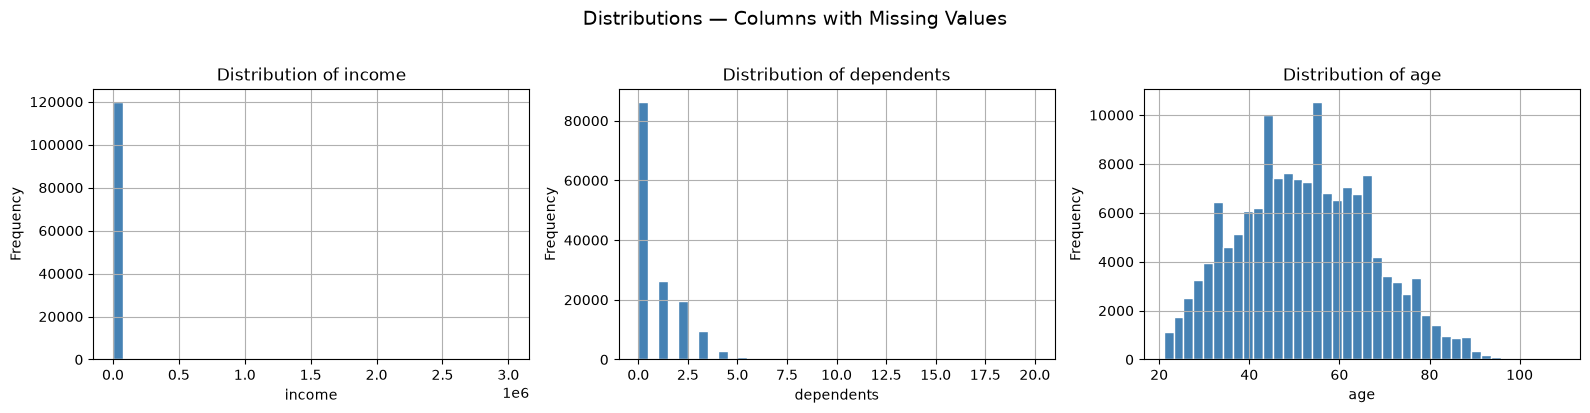

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, missing_cols):
    df[col].hist(bins=40, ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(f'Distribution of {col}', fontsize=12)
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
plt.suptitle('Distributions — Columns with Missing Values', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

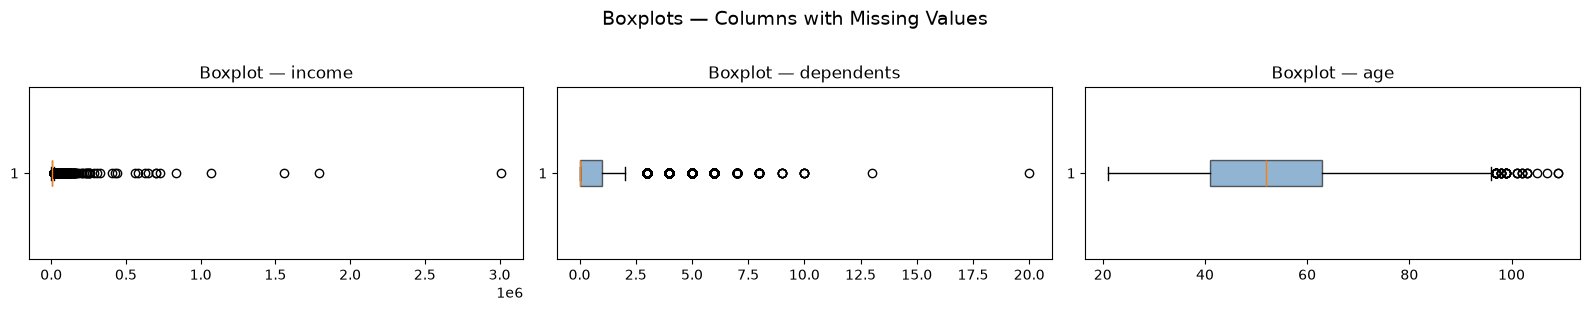

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 3))
for ax, col in zip(axes, missing_cols):
    ax.boxplot(df[col].dropna(), orientation='horizontal',
               patch_artist=True, boxprops=dict(facecolor='steelblue', alpha=0.6))
    ax.set_title(f'Boxplot — {col}', fontsize=12)
plt.suptitle('Boxplots — Columns with Missing Values', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 5. Impute Missing Values (Median)

In [10]:
for col in missing_cols:
    med = df[col].median()
    df[col] = df[col].fillna(med)
    print(f'  {col:<15} filled with median = {med:.2f}')

print(f'\nTotal remaining missing values: {df.isnull().sum().sum()}')

  income          filled with median = 5400.00
  dependents      filled with median = 0.00
  age             filled with median = 52.00

Total remaining missing values: 0


## 6. Full Dataset — Distributions & Skewness

In [11]:
numeric_cols = df.select_dtypes(include='number').columns.tolist()
skewness = df[numeric_cols].skew().sort_values(ascending=False).round(3)
print('Skewness (sorted):\n')
print(skewness.to_string())

Skewness (sorted):

income               126.890
util_rate             97.433
debt_ratio            94.980
late_60_89            25.424
late_90_plus          25.107
late_30_59            24.475
real_estate_loans      3.485
default                3.464
dependents             1.620
open_loans             1.222
age                    0.193


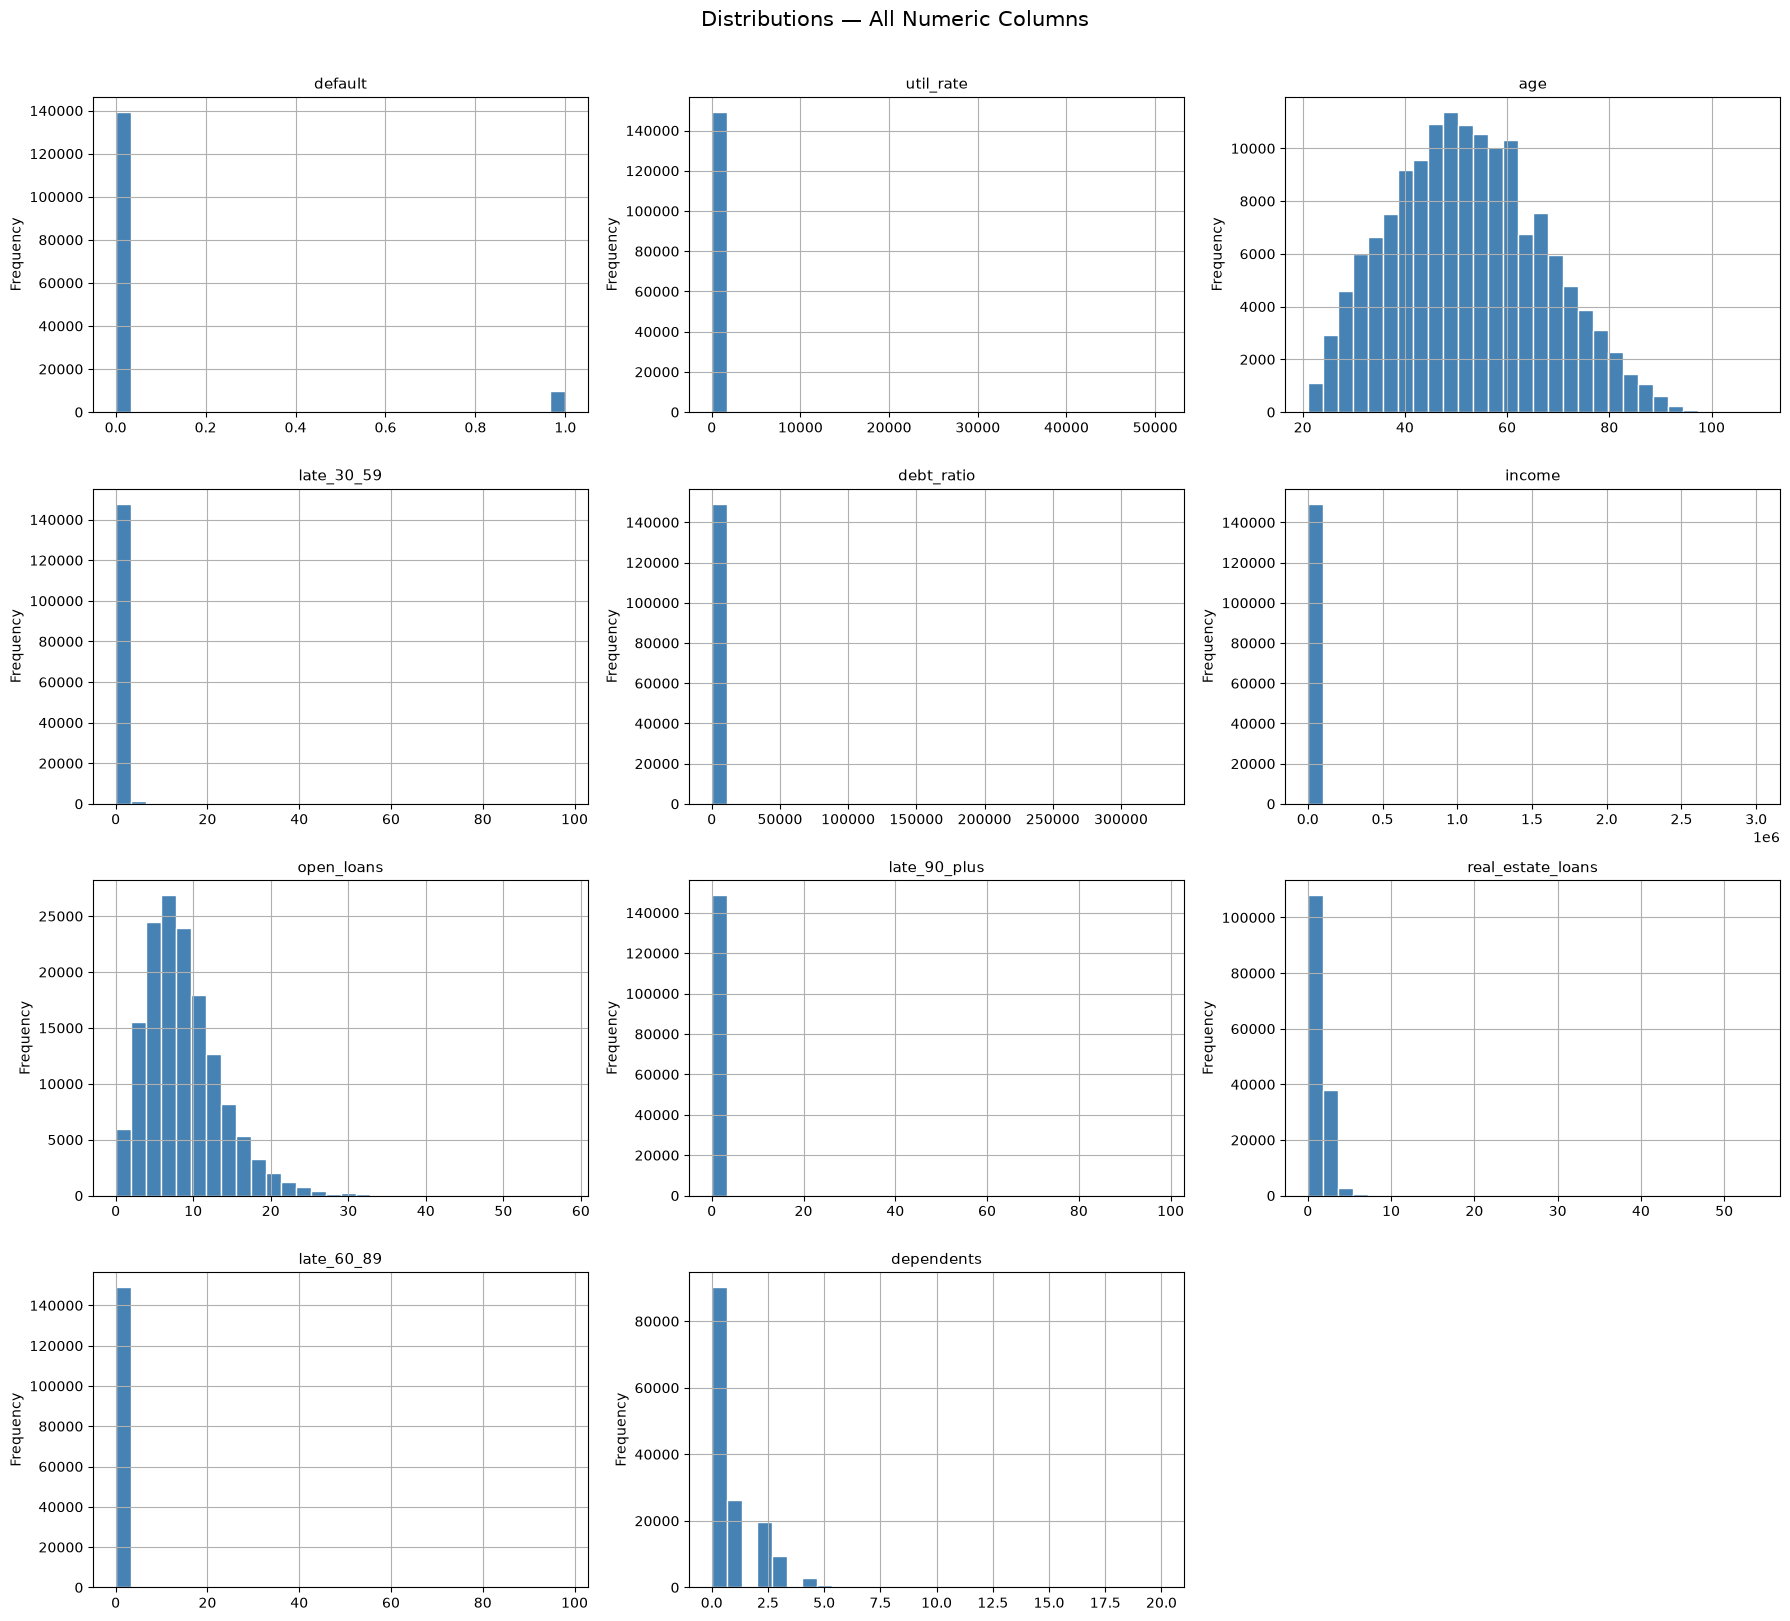

In [12]:
n_cols = 3
n_rows = -(-len(numeric_cols) // n_cols)  # ceiling division
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    df[col].hist(bins=30, ax=axes[i], color='steelblue', edgecolor='white')
    axes[i].set_title(f'{col}', fontsize=11)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frequency')

# Hide empty subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distributions — All Numeric Columns', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

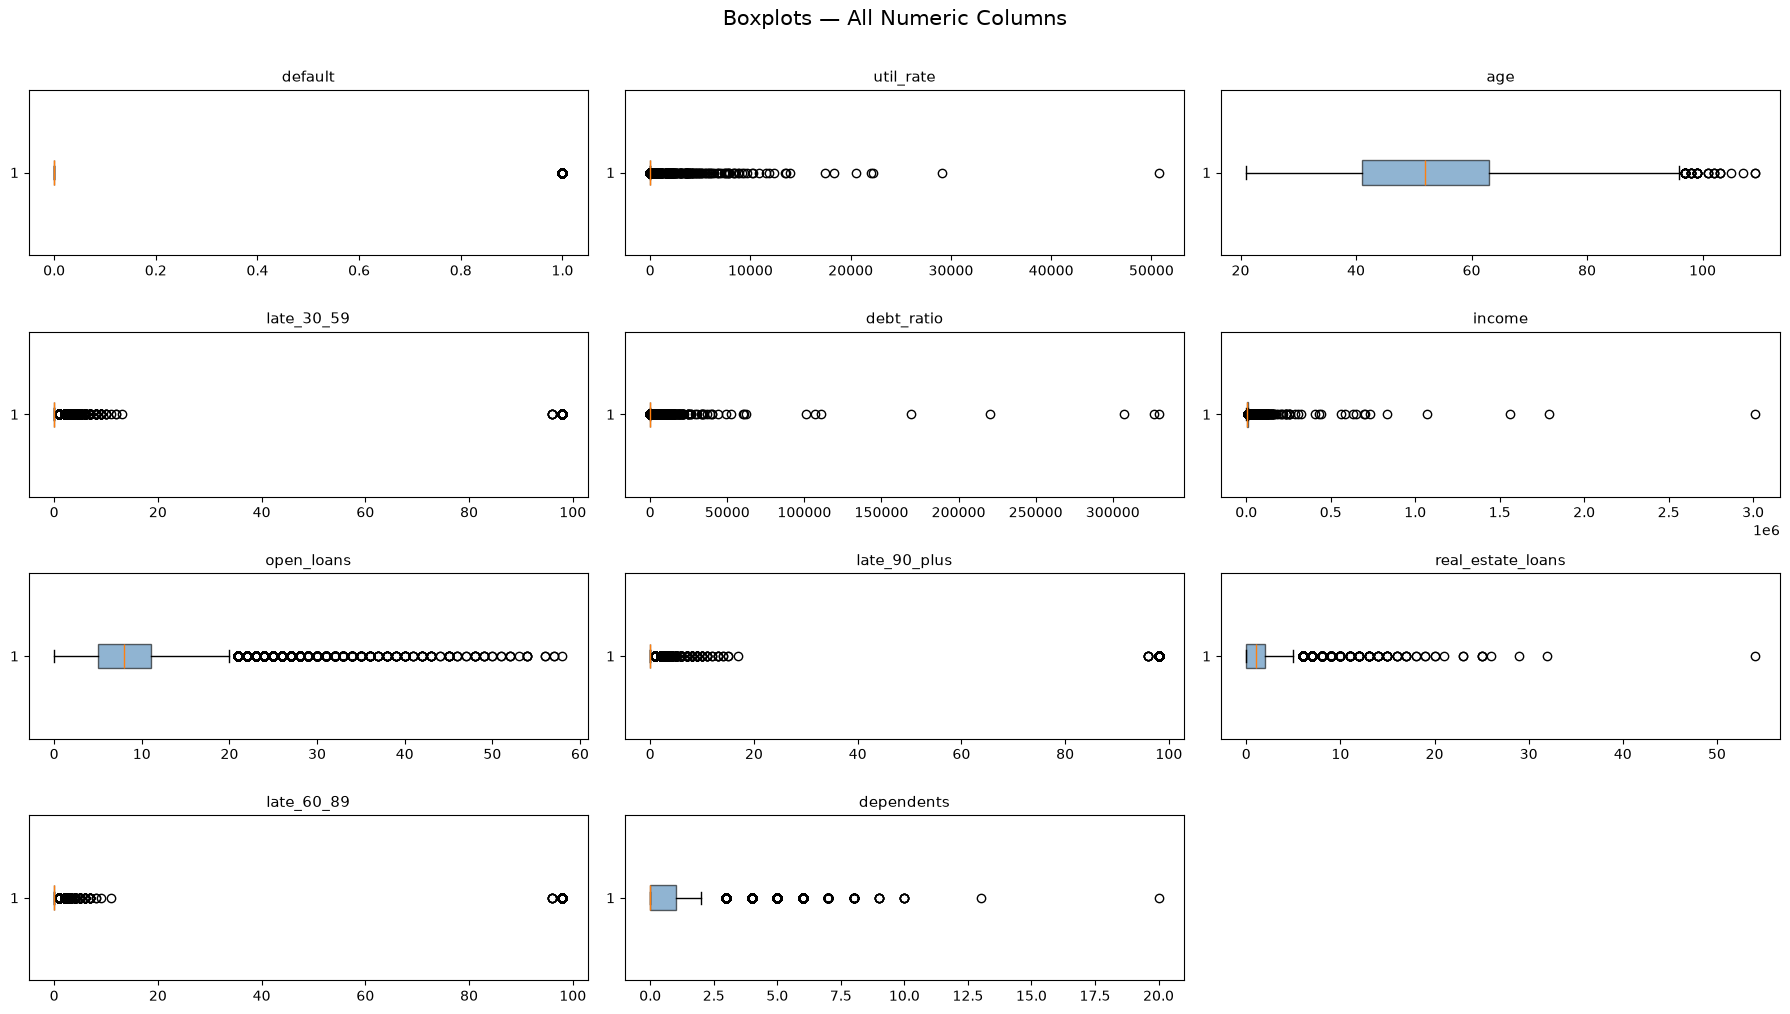

In [13]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 2.5))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df[col], orientation='horizontal',
                    patch_artist=True, boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[i].set_title(f'{col}', fontsize=11)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots — All Numeric Columns', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

## 7. Categorical Columns

In [14]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
if cat_cols:
    print('Categorical columns:', cat_cols)
else:
    print('No categorical columns found.')

No categorical columns found.


## 8. Feture eng

In [15]:
df["total_late"] = (
    df["late_30_59"]
    + df["late_60_89"]
    + df["late_90_plus"]
)
df["has_late_payment"] = (
    df["total_late"] > 0
).astype(int)
df["income_per_dependent"] = (
    df["income"] /
    (df["dependents"] + 1)
)
df["debt_per_loan"] = (
    df["debt_ratio"] /
    (df["open_loans"] + 1)
)

## 9. Final Summary & Save

In [16]:
print(f'Shape          : {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Missing values : {df.isnull().sum().sum()}')
print('\nData types:')
print(df.dtypes.value_counts().to_string())
print('\nMissing per column:')
print(df.isnull().sum().to_string())

Shape          : 149,391 rows x 15 columns
Missing values : 0

Data types:
int64      8
float64    7

Missing per column:
default                 0
util_rate               0
age                     0
late_30_59              0
debt_ratio              0
income                  0
open_loans              0
late_90_plus            0
real_estate_loans       0
late_60_89              0
dependents              0
total_late              0
has_late_payment        0
income_per_dependent    0
debt_per_loan           0


In [17]:
out_path = os.path.abspath(os.path.join('..', 'data', 'clean_cs_training.csv'))
df.to_csv(out_path, index=False)
print(f'Saved to: {out_path}')

Saved to: c:\Users\User\Downloads\Credit-risk-prediction-main\Credit-risk-prediction-main\data\clean_cs_training.csv
